In [141]:
import pandas as pd
import json
from ast import literal_eval
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter
import re
from datetime import datetime, timedelta
import numpy as np

In [142]:
def remove_message_timestamp(message):
    regex = r"'time': \d+, "
    new_message = re.sub(regex, '', str(message))
    regex = r"'dpId': \d+, "
    new_message = re.sub(regex, '', str(new_message))
    return eval(new_message)

def remove_invalid_codes(message):
    valid_codes = ['switch_led', 'switch_1', 'presence_state', 'doorcontact_state']
    result = []
    for state in message:
        if state['code'] in valid_codes:
            result.append(state)
    if len(result) > 0:
        return result
    else:
        return np.nan

def time_interval(dt, minutes=60):
    total_seconds = timedelta(hours=dt.hour, minutes=dt.minute, seconds=dt.second).total_seconds()
    interval = total_seconds // (minutes * 60)
    return int(interval)

def device_change_heatmap_1(df):
    df['interval'] = df['timeStamp'].apply(time_interval)
    routine_dict = pd.DataFrame({'interval': range(24)})
    for device in unique_devices:
        a = df[df['devId'] == device].groupby('interval')['devId'].count().to_frame().rename({'devId': device}, axis=1)
        routine_dict = routine_dict.merge(a, on='interval', how='left')

    routine_dict = routine_dict.drop('interval', axis=1)
    routine_map = routine_dict.fillna(0).T
    fig = plt.figure(figsize=(25, 5))
    # fig.subplots_adjust(left=0.2)
    heatmap = sns.heatmap(routine_map, vmin=-1, vmax=24, annot=True, cmap='Blues', fmt='.0f',
                          linecolor='black', annot_kws={'size': 16, 'weight': 'heavy'})
    heatmap.collections[0].colorbar.ax.tick_params(labelsize=22)
    plt.xticks(fontsize=22)
    plt.yticks(fontsize=22, rotation=0)
    plt.xlabel('Time of day', fontsize=22)
    return fig

def device_change_heatmap_Teste(df, unique_devices):
    df_meio_semana = df.query('day_week != "Sunday" and day_week != "Saturday"')
    df_fim_semana = df.query('day_week == "Sunday" or day_week == "Saturday"')
    
    # df_meio_semana = df_meio_semana[df_meio_semana['devId'] != 'Sensor_presence']
    # df_fim_semana = df_fim_semana[df_fim_semana['devId'] != 'Sensor_presence']

    df_meio_semana['interval'] = df_meio_semana['timeStamp'].apply(time_interval)
    df_fim_semana['interval'] = df_fim_semana['timeStamp'].apply(time_interval)
    routine_meio_semana = pd.DataFrame({'interval': range(24)})
    routine_fim_semana = pd.DataFrame({'interval': range(24)})

    for device in unique_devices:
        a = df_meio_semana[df_meio_semana['devId'] == device].groupby('interval')['devId'].count().to_frame().rename({'devId': device}, axis=1)
        b = df_fim_semana[df_fim_semana['devId'] == device].groupby('interval')['devId'].count().to_frame().rename({'devId': device}, axis=1)

        routine_meio_semana = routine_meio_semana.merge(a, on='interval', how='left')
        routine_fim_semana = routine_fim_semana.merge(b, on='interval', how='left')

    routine_meio_semana = routine_meio_semana.drop('interval', axis=1)
    routine_meio_semana = routine_meio_semana.fillna(0).T

    routine_fim_semana = routine_fim_semana.drop('interval', axis=1)
    routine_fim_semana = routine_fim_semana.fillna(0).T


    fig, axes = plt.subplots(2, 1, figsize=(25, 5))
    heatmap = sns.heatmap(routine_meio_semana, ax=axes[0], vmin=-1, vmax=24, annot=True, cmap='Greens', fmt='.0f',
                          linecolor='black', annot_kws={'size': 16, 'weight': 'heavy'})
    heatmap.collections[0].colorbar.ax.tick_params(labelsize=22)
    axes[0].set_title('Weekdays', fontsize=16)
    axes[0].set_xlabel('Time of day', fontsize=12)


    heatmap = sns.heatmap(routine_fim_semana, ax=axes[1], vmin=-1, vmax=24, annot=True, cmap='Greens', fmt='.0f',
                          linecolor='black', annot_kws={'size': 16, 'weight': 'heavy'})
    heatmap.collections[0].colorbar.ax.tick_params(labelsize=22)
    axes[1].set_title('Weekend', fontsize=16)
    axes[1].set_xlabel('Time of day', fontsize=12)

    plt.subplots_adjust(wspace=0.7, hspace=0.7)
    return fig

Sensor_presence: 1044
Plug_fan: 0
Light_bulb: 5
Plug_pc: 0


/tmp/ipykernel_136196/3708217349.py:50: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_meio_semana['interval'] = df_meio_semana['timeStamp'].apply(time_interval)
/tmp/ipykernel_136196/3708217349.py:51: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_fim_semana['interval'] = df_fim_semana['timeStamp'].apply(time_interval)


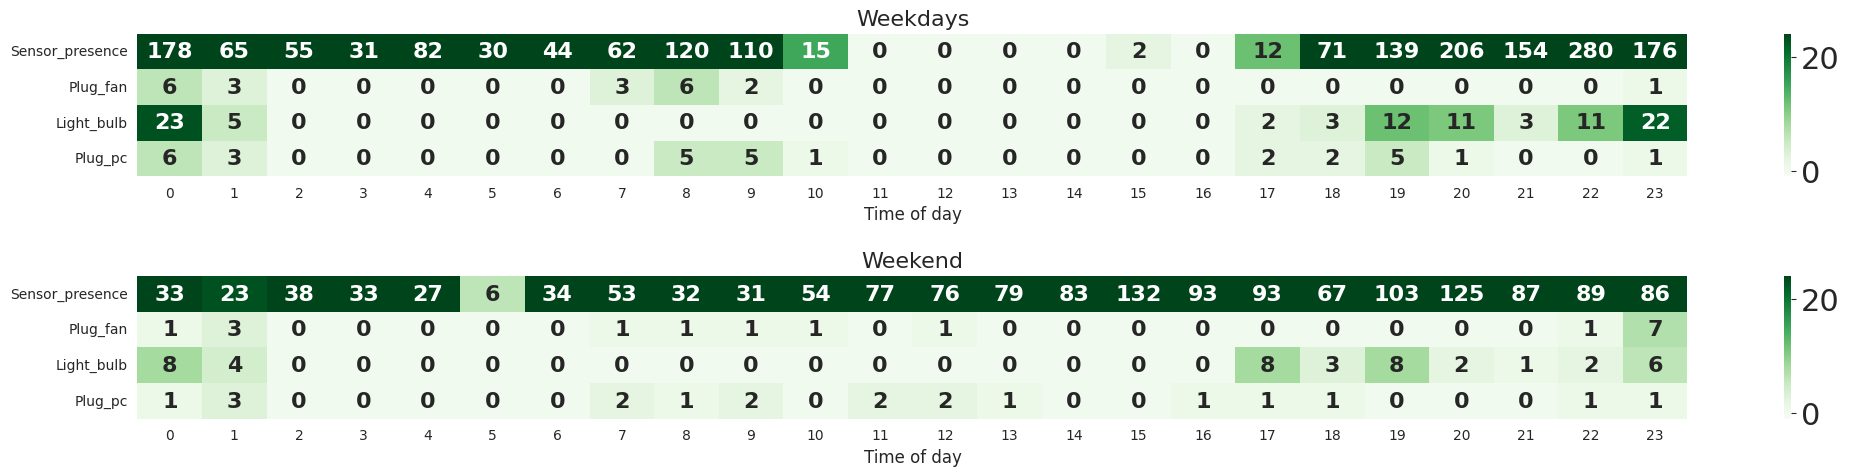

In [143]:
message_list = []
hour_list = []
with open("dados.json", "r") as json:
    data = json.read()
    for line in data.split('\n')[1:-1]:
        hour_list.append(eval(line)['hora'])
        dict_msg = eval(eval(line)['mensagem'].replace('true', 'True').replace('false', 'False'))['bizData']
        message_list.append(dict_msg)
    json.close()

df = pd.DataFrame(message_list).rename(columns={'properties': 'message'})
df['timeStamp'] = hour_list
df['message'] = df['message'].astype(str)

dicionario = {
    'ebfe6c248a7dfe6910qdcb': 'Plug_fan',
    'eb061b979815289561tyqf': 'Sensor_presence',
    'eb31770a1d7812125degzr': 'Light_bulb',
    'eb176a71685a57c19arlbp': 'abertura',
    'ebcc9b86347718a3808ezt': 'Plug_pc',
    'ebf1d890916d1a73b4vtnv': 'temp_humidade'
}

df['devId'] = df['devId'].apply(lambda x: dicionario[x])



df['message'] = df['message'].apply(remove_message_timestamp)
df['message'] = df['message'].apply(remove_invalid_codes)
df['timeStamp'] = df['timeStamp'].apply(lambda string: datetime.strptime(string, '%Y-%m-%dT%H:%M:%S.%f'))

df = df[df['message'].notna()].reset_index(drop=True)
df["day_week"] = df["timeStamp"].dt.day_name()

# unique_devices = df['devId'].unique()

unique_devices = ['Sensor_presence', 'Plug_fan', 'Light_bulb', 'Plug_pc']

for device in unique_devices:
    result = (df[df['devId'] == device]['message'].shift(1) == df[df['devId'] == device]['message']).sum()
    print(f'{device}: {result}')

remove_index = []
for device in unique_devices:
    result = df[df['devId'] == device][(df[df['devId'] == device]['message'].shift(1) == df[df['devId'] == device]['message']).values].index.tolist()
    if len(result) > 0:
        remove_index.extend(result)
df = df.drop(remove_index)


# df_heatmap = df[df['day_week'] == 'Monday']
df_heatmap = df.query('day_week != "Sunday" and day_week != "Saturday"')
# df_heatmap = df.query('day_week == "Sunday" or day_week == "Saturday"')

# df_heatmap = df_heatmap[df_heatmap['devId'] != 'presenca']
# graph = device_change_heatmap_1(df_heatmap)
graph = device_change_heatmap_Teste(df, unique_devices)
graph.savefig("real.png", bbox_inches='tight')

Sensor_presence: 0
Plug_fan: 0
Light_bulb: 0
Plug_pc: 0


/tmp/ipykernel_136196/3708217349.py:50: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_meio_semana['interval'] = df_meio_semana['timeStamp'].apply(time_interval)
/tmp/ipykernel_136196/3708217349.py:51: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_fim_semana['interval'] = df_fim_semana['timeStamp'].apply(time_interval)


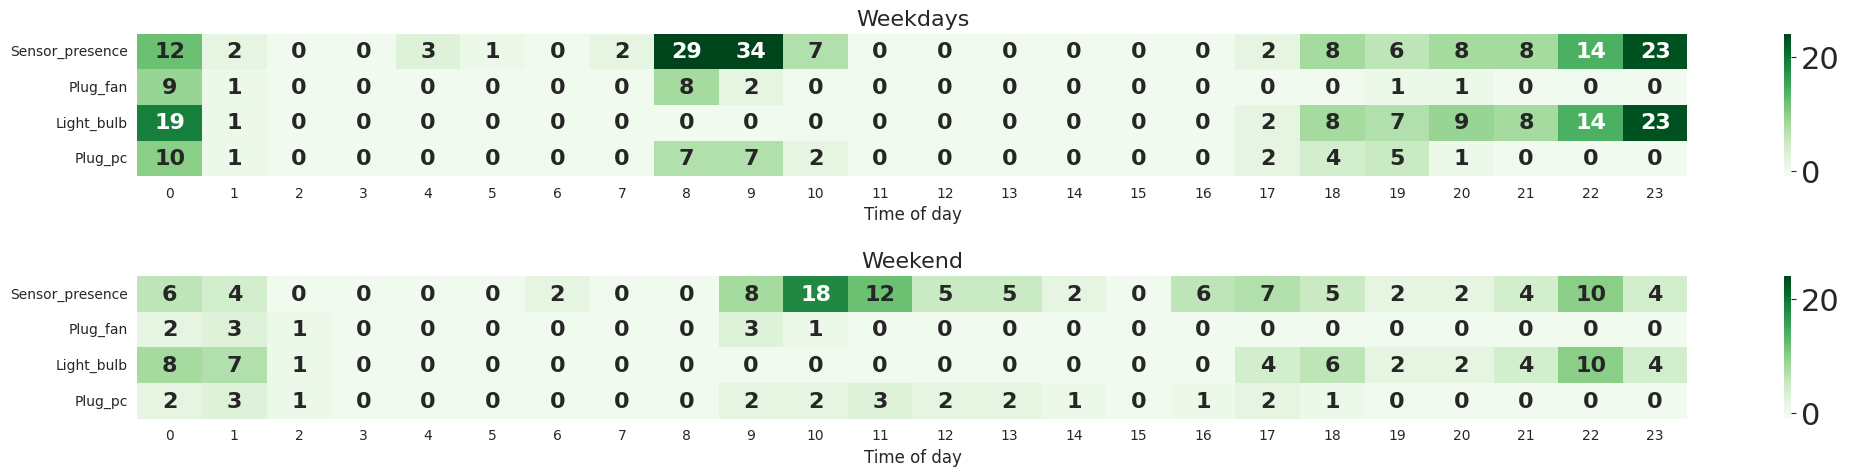

In [144]:
df_gerado = pd.read_csv('../dados/original/completo/dados-validacao-temp.csv')
colunas = ['devId', 'productKey', 'message', 'timeStamp']
# df_gerado.drop('devId', axis=1, inplace=True)
# df_gerado['devId'] = df_gerado['device']

dicionario = {
    'QUARTO_PLUG_02-004': 'Plug_fan',
    'QUARTO_SENSOR_PRESENCA-002': 'Sensor_presence',
    'QUARTO_LAMPADA-001': 'Light_bulb',
    'QUARTO_PLUG_01-003': 'Plug_pc'
}

df_gerado['devId'] = df_gerado['device'].apply(lambda x: dicionario[x])


df_gerado = df_gerado[colunas]

df_gerado['timeStamp'] = df_gerado['timeStamp'].apply(lambda string: datetime.strptime(string, '%Y-%m-%d %H:%M:%S.%f'))
df_gerado["day_week"] = df_gerado["timeStamp"].dt.day_name()

# unique_devices = df_gerado['devId'].unique()
unique_devices = ['Sensor_presence', 'Plug_fan', 'Light_bulb', 'Plug_pc']

for device in unique_devices:
    result = (df_gerado[df_gerado['devId'] == device]['message'].shift(1) == df_gerado[df_gerado['devId'] == device]['message']).sum()
    print(f'{device}: {result}')


# df_heatmap = df_gerado[df_gerado['day_week'] == 'Monday']
df_heatmap = df_gerado.query('day_week != "Sunday" and day_week != "Saturday"')
# df_heatmap = df_gerado.query('day_week == "Sunday" or day_week == "Saturday"')

# df_heatmap = df_heatmap[df_heatmap['devId'] != 'presenca']
# graph = device_change_heatmap_1(df_heatmap)
graph = device_change_heatmap_Teste(df_gerado, unique_devices)
graph.savefig("gerado.png", bbox_inches='tight')

# TESTE

Sensor_presence: 0
Plug_fan: 0
Light_bulb: 0
Plug_pc: 0


/tmp/ipykernel_136196/3708217349.py:50: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_meio_semana['interval'] = df_meio_semana['timeStamp'].apply(time_interval)
/tmp/ipykernel_136196/3708217349.py:51: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_fim_semana['interval'] = df_fim_semana['timeStamp'].apply(time_interval)


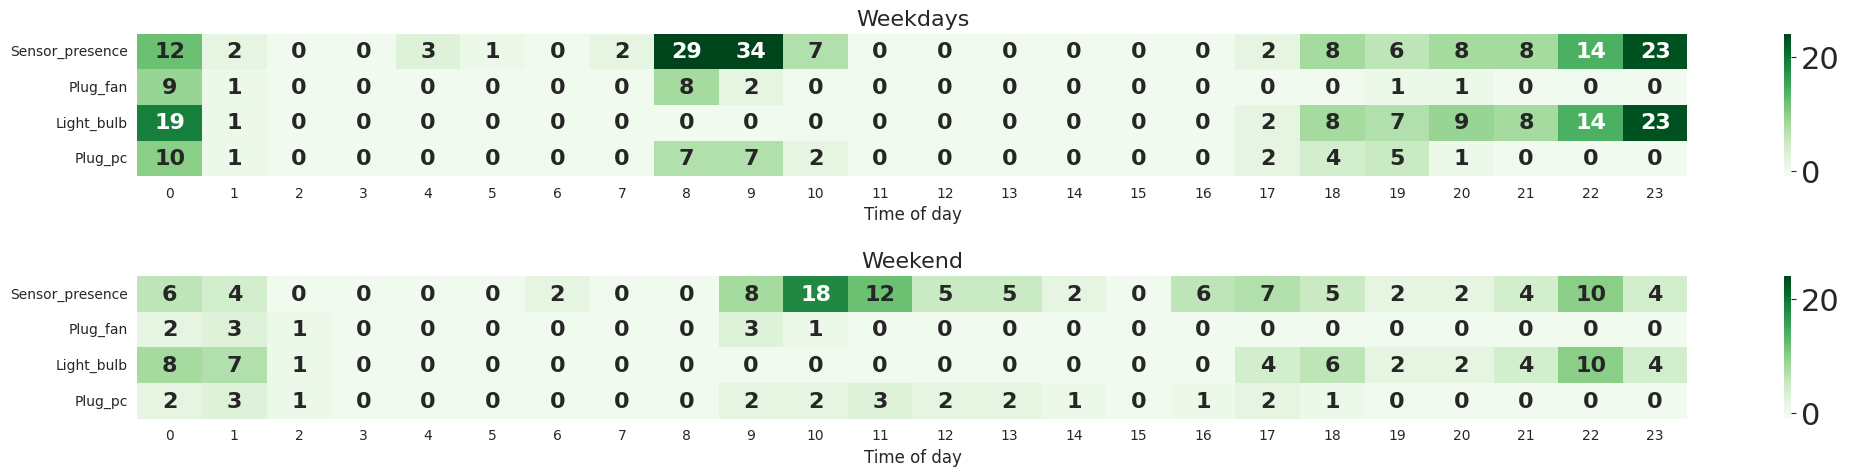

In [145]:




df_gerado = pd.read_csv('../dados/original/completo/dados-validacao-temp.csv')
colunas = ['devId', 'productKey', 'message', 'timeStamp']
unique_devices = ['Sensor_presence', 'Plug_fan', 'Light_bulb', 'Plug_pc']

dicionario = {
    'QUARTO_PLUG_02-004': 'Plug_fan',
    'QUARTO_SENSOR_PRESENCA-002': 'Sensor_presence',
    'QUARTO_LAMPADA-001': 'Light_bulb',
    'QUARTO_PLUG_01-003': 'Plug_pc'
}

df_gerado['devId'] = df_gerado['device'].apply(lambda x: dicionario[x])


df_gerado = df_gerado[colunas]

df_gerado['timeStamp'] = df_gerado['timeStamp'].apply(lambda string: datetime.strptime(string, '%Y-%m-%d %H:%M:%S.%f'))
df_gerado["day_week"] = df_gerado["timeStamp"].dt.day_name()



for device in unique_devices:
    result = (df_gerado[df_gerado['devId'] == device]['message'].shift(1) == df_gerado[df_gerado['devId'] == device]['message']).sum()
    print(f'{device}: {result}')


# df_heatmap = df_gerado[df_gerado['day_week'] == 'Monday']
# df_heatmap = df_gerado.query('day_week != "Sunday" and day_week != "Saturday"')
# df_heatmap = df_gerado.query('day_week == "Sunday" or day_week == "Saturday"')

# df_heatmap = df_heatmap[df_heatmap['devId'] != 'presenca']
graph = device_change_heatmap_Teste(df_gerado, unique_devices)
graph.savefig("gerado.png", bbox_inches='tight')

/tmp/ipykernel_136196/3708217349.py:50: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_meio_semana['interval'] = df_meio_semana['timeStamp'].apply(time_interval)
/tmp/ipykernel_136196/3708217349.py:51: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_fim_semana['interval'] = df_fim_semana['timeStamp'].apply(time_interval)


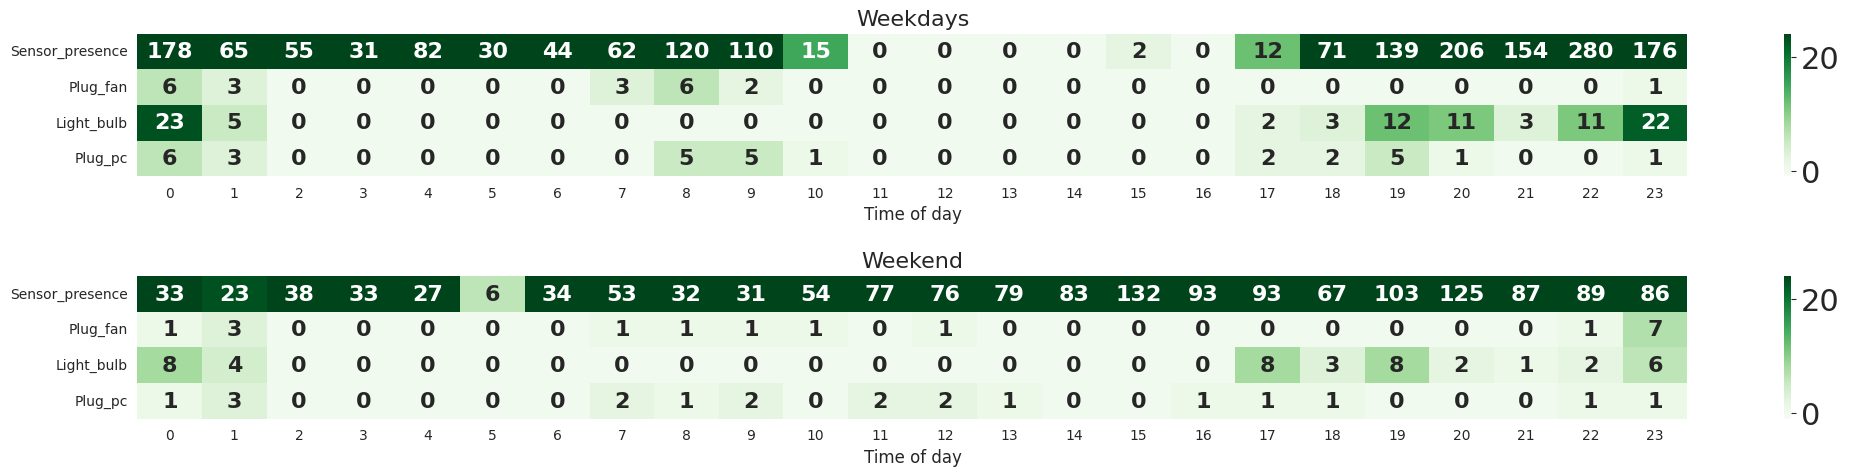

In [146]:
graph = device_change_heatmap_Teste(df, unique_devices)